In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("nba-players.csv")
print(df.head())

   Unnamed: 0             name  gp   min  pts  fgm  fga    fg  3p_made  3pa  \
0           0   Brandon Ingram  36  27.4  7.4  2.6  7.6  34.7      0.5  2.1   
1           1  Andrew Harrison  35  26.9  7.2  2.0  6.7  29.6      0.7  2.8   
2           2   JaKarr Sampson  74  15.3  5.2  2.0  4.7  42.2      0.4  1.7   
3           3      Malik Sealy  58  11.6  5.7  2.3  5.5  42.6      0.1  0.5   
4           4      Matt Geiger  48  11.5  4.5  1.6  3.0  52.4      0.0  0.1   

   ...  fta    ft  oreb  dreb  reb  ast  stl  blk  tov  target_5yrs  
0  ...  2.3  69.9   0.7   3.4  4.1  1.9  0.4  0.4  1.3            0  
1  ...  3.4  76.5   0.5   2.0  2.4  3.7  1.1  0.5  1.6            0  
2  ...  1.3  67.0   0.5   1.7  2.2  1.0  0.5  0.3  1.0            0  
3  ...  1.3  68.9   1.0   0.9  1.9  0.8  0.6  0.1  1.0            1  
4  ...  1.9  67.4   1.0   1.5  2.5  0.3  0.3  0.4  0.8            1  

[5 rows x 22 columns]


In [ ]:
df = df.drop(columns=['Unnamed: 0'])
# Drop unnecessary columns
df = df.drop(columns=['name', 'target_5yrs'], errors='ignore')

In [4]:
# Standardize features (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
# -------------------------------
# 1. K-Means Clustering
# -------------------------------

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print("\nK-Means Clusters Assigned:")
print(df['KMeans_Cluster'].value_counts())

c:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\PC\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\PC\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


K-Means Clusters Assigned:
KMeans_Cluster
1    597
2    333
3    293
0    117
Name: count, dtype: int64


c:\Users\PC\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [6]:
# -------------------------------
# 2. DBSCAN Clustering
# -------------------------------

dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

print("\nDBSCAN Clusters Assigned:")
print(df['DBSCAN_Cluster'].value_counts())


DBSCAN Clusters Assigned:
DBSCAN_Cluster
-1    736
 0    591
 1      5
 2      4
 3      4
Name: count, dtype: int64


In [7]:
# -------------------------------
# 3. Hierarchical Clustering
# -------------------------------

hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = hier_labels

print("\nHierarchical Clusters Assigned:")
print(df['Hierarchical_Cluster'].value_counts())


Hierarchical Clusters Assigned:
Hierarchical_Cluster
0    710
1    278
3    222
2    130
Name: count, dtype: int64


In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X, labels, model_name):
    # Some models (like DBSCAN) can give all -1s (noise) — avoid error
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
        db = davies_bouldin_score(X, labels)
        ch = calinski_harabasz_score(X, labels)
        print(f"\n📊 {model_name} Evaluation:")
        print(f"Silhouette Score: {sil:.3f}")
        print(f"Davies–Bouldin Index: {db:.3f}")
        print(f"Calinski–Harabasz Index: {ch:.3f}")
    else:
        print(f"\n⚠️ {model_name} produced only one cluster or all noise.")

# Evaluate each model
evaluate_clustering(X_scaled, kmeans_labels, "K-Means")
evaluate_clustering(X_scaled, dbscan_labels, "DBSCAN")
evaluate_clustering(X_scaled, hier_labels, "Hierarchical")


📊 K-Means Evaluation:
Silhouette Score: 0.230
Davies–Bouldin Index: 1.369
Calinski–Harabasz Index: 473.221

📊 DBSCAN Evaluation:
Silhouette Score: -0.197
Davies–Bouldin Index: 1.863
Calinski–Harabasz Index: 76.175

📊 Hierarchical Evaluation:
Silhouette Score: 0.187
Davies–Bouldin Index: 1.581
Calinski–Harabasz Index: 394.329


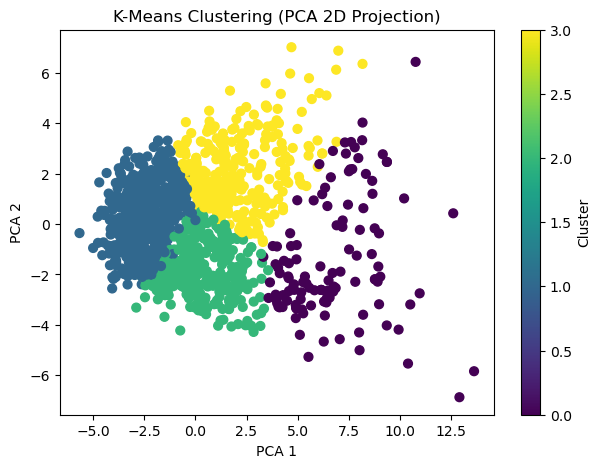

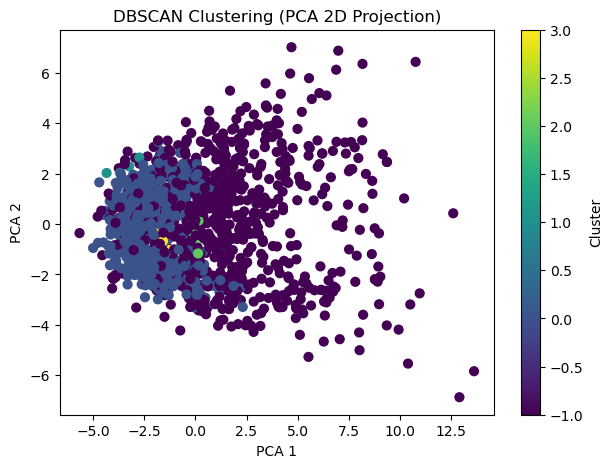

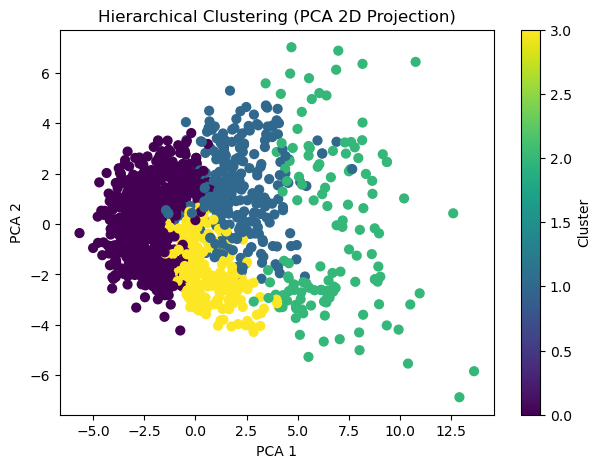

In [10]:
# --- PCA to reduce to 2D for visualization ---
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- Plot function ---
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(7,5))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=40)
    plt.title(title)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(label='Cluster')
    plt.show()

# --- Plot each model ---
plot_clusters(X_pca, kmeans_labels, "K-Means Clustering (PCA 2D Projection)")
plot_clusters(X_pca, dbscan_labels, "DBSCAN Clustering (PCA 2D Projection)")
plot_clusters(X_pca, hier_labels, "Hierarchical Clustering (PCA 2D Projection)")